In [72]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

from src.qc.qc_events import load_behavior_qc_tables

events_df, session_summary_df = load_behavior_qc_tables(
    pdata_root=pdata_root,
    filename="behavior_QC.h5"
)

from src.utils.pdata_organize import make_session_availability_summary

session_availability_df = make_session_availability_summary(
    events_df=events_df,
    windows_df=windows_df,
    min_session_duration_s=900,
    min_valid_events=3,
)

from src.utils.pdata_organize import add_day_bins_to_sessions

session_day_df = add_day_bins_to_sessions(
    session_availability_df,
    use_good_sessions_only=True,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (103980, 40)
Valid windows: (101861, 40)
[LOADED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


In [3]:
session_day_df

,animal,date,phase,session_duration_s,n_events_total,n_events_valid,short_recording,enough_valid_events,good_session_basic,nwin_LED_off_post,...,nwin_tone_off_post,nwin_tone_off_pre,nwin_tone_on_post,nwin_tone_on_pre,n_valid_windows_total,date_dt,phase_day_number_good,n_good_sessions_in_phase,normalized_phase_day_good,phase_day_bin
0,NML_04,2025_12_27,habituation,1310.8,42,42,False,True,True,42,...,0,0,0,0,503,2025-12-27,1.0,16.0,0.000000,early
1,NML_04,2025_12_28,habituation,1473.4,43,43,False,True,True,43,...,0,0,0,0,516,2025-12-28,2.0,16.0,0.066667,early
2,NML_04,2025_12_29,habituation,1254.5,41,41,False,True,True,41,...,0,0,0,0,492,2025-12-29,3.0,16.0,0.133333,early
3,NML_04,2025_12_30,habituation,1624.2,53,53,False,True,True,53,...,0,0,0,0,636,2025-12-30,4.0,16.0,0.200000,early
4,NML_04,2025_12_31,habituation,1326.6,41,41,False,True,True,41,...,0,0,0,0,492,2025-12-31,5.0,16.0,0.266667,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,NML_08,2026_03_17,tone_air_training,1235.7,48,48,False,True,True,0,...,48,48,48,48,576,2026-03-17,6.0,10.0,0.555556,middle
209,NML_08,2026_03_18,tone_air_training,1236.0,51,51,False,True,True,0,...,51,51,51,51,612,2026-03-18,7.0,10.0,0.666667,middle
210,NML_08,2026_03_19,tone_air_training,1214.1,50,50,False,True,True,0,...,50,50,50,50,600,2026-03-19,8.0,10.0,0.777778,late
211,NML_08,2026_03_20,tone_air_training,1220.1,48,48,False,True,True,0,...,48,48,48,48,576,2026-03-20,9.0,10.0,0.888889,late


In [73]:
import numpy as np
import pandas as pd


def make_habituation_session_summary(
    encoder_epoch_df,
    metrics=None,
    keep_overlap=True,
    require_good_session=True,
    require_valid_window=True,
):
    """
    Make one row per animal/date for habituation/repeated wheel exposure.

    This summarizes available epoch windows within each session.
    """

    if metrics is None:
        metrics = [
            "frac_forward",
            "frac_stationary",
            "frac_moving",
            "mean_speed_path_cms",
            "mean_speed_net_cms",
        ]

    df = encoder_epoch_df.copy()

    df = df[df["phase"] == "habituation"].copy()

    if require_good_session and "good_session_basic" in df.columns:
        df = df[df["good_session_basic"] == True].copy()

    if require_valid_window and "valid_window" in df.columns:
        df = df[df["valid_window"] == True].copy()

    if not keep_overlap and "overlap_flag" in df.columns:
        df = df[df["overlap_flag"] == False].copy()

    metrics = [m for m in metrics if m in df.columns]

    id_cols = [
        "animal",
        "date",
        "phase",
        "phase_day_from_date",
        "phase_session_number",
        "phase_session_start_min",
        "rig_session_number",
        "rig_session_start_min",
        "recording_duration_min",
    ]

    id_cols = [c for c in id_cols if c in df.columns]

    agg_dict = {m: (m, "mean") for m in metrics}
    agg_dict.update({
        "n_windows": ("epoch_name", "count"),
        "n_anchors": ("anchor_name", "nunique"),
    })

    session_df = (
        df
        .groupby(id_cols, observed=False)
        .agg(**agg_dict)
        .reset_index()
        .sort_values(["animal", "phase_session_number"])
        .reset_index(drop=True)
    )

    return session_df


hab_session_df = make_habituation_session_summary(encoder_epoch_df)
hab_session_df.head()

,animal,date,phase,phase_day_from_date,phase_session_number,phase_session_start_min,rig_session_number,rig_session_start_min,recording_duration_min,frac_forward,frac_stationary,frac_moving,mean_speed_path_cms,mean_speed_net_cms,n_windows,n_anchors
0,NML_04,2025_12_27,habituation,1,1,0.000000,1,0.000000,21.846667,0.193729,0.642849,0.357151,0.798838,0.096692,503,6
1,NML_04,2025_12_28,habituation,2,2,21.846667,2,21.846667,24.556667,0.162599,0.704591,0.295409,0.540097,0.074092,516,6
2,NML_04,2025_12_29,habituation,3,3,46.403333,3,46.403333,20.908333,0.230797,0.661419,0.338581,0.688970,0.355807,492,6
3,NML_04,2025_12_30,habituation,4,4,67.311667,4,67.311667,27.070000,0.264549,0.667741,0.332259,0.912839,0.713102,636,6
4,NML_04,2025_12_31,habituation,5,5,94.381667,5,94.381667,22.110000,0.277843,0.677627,0.322373,0.927110,0.811146,492,6


In [5]:
def estimate_minimum_stable_session(
    session_df,
    outcome="frac_forward",
    session_col="phase_session_number",
    animal_col="animal",
    last_n_reference=3,
    tolerance=0.05,
    require_all_future=True,
):
    """
    Estimate earliest session where group mean is close to the late-session reference.

    For fraction outcomes, tolerance can be absolute, e.g. ±0.05.
    """

    df = session_df.copy()
    df = df[np.isfinite(df[outcome])].copy()

    # Late reference per animal = mean of last N sessions for that animal
    late_ref = (
        df.sort_values([animal_col, session_col])
        .groupby(animal_col)
        .tail(last_n_reference)
        .groupby(animal_col)[outcome]
        .mean()
        .reset_index(name=f"{outcome}_late_ref")
    )

    df = df.merge(late_ref, on=animal_col, how="left")

    df["abs_diff_from_late_ref"] = (
        df[outcome] - df[f"{outcome}_late_ref"]
    ).abs()

    # Group-level summary by session
    group_df = (
        df
        .groupby(session_col)
        .agg(
            mean_outcome=(outcome, "mean"),
            sem_outcome=(outcome, lambda x: x.std(ddof=1) / np.sqrt(len(x))),
            mean_abs_diff=("abs_diff_from_late_ref", "mean"),
            max_abs_diff=("abs_diff_from_late_ref", "max"),
            n_animals=(animal_col, "nunique"),
        )
        .reset_index()
    )

    group_df["within_tolerance_mean"] = (
        group_df["mean_abs_diff"] <= tolerance
    )

    group_df["within_tolerance_all_animals"] = (
        group_df["max_abs_diff"] <= tolerance
    )

    # Choose criterion
    criterion_col = (
        "within_tolerance_all_animals"
        if require_all_future
        else "within_tolerance_mean"
    )

    candidate_sessions = []

    for s in sorted(group_df[session_col].unique()):
        future = group_df[group_df[session_col] >= s]

        if future[criterion_col].all():
            candidate_sessions.append(s)

    min_session = candidate_sessions[0] if len(candidate_sessions) > 0 else np.nan

    return min_session, group_df, df

In [6]:
outcomes = [
    ("frac_forward", 0.05),
    ("frac_stationary", 0.05),
    ("frac_moving", 0.05),
    ("mean_speed_path_cms", 0.50),  # example absolute cm/s tolerance
    ("mean_speed_net_cms", 0.50),
]

minimum_rows = []

for outcome, tol in outcomes:
    min_session, group_df, detail_df = estimate_minimum_stable_session(
        hab_session_df,
        outcome=outcome,
        last_n_reference=3,
        tolerance=tol,
        require_all_future=False,  # group-level criterion first
    )

    minimum_rows.append({
        "outcome": outcome,
        "tolerance": tol,
        "estimated_minimum_session": min_session,
    })

minimum_summary_df = pd.DataFrame(minimum_rows)
minimum_summary_df

,outcome,tolerance,estimated_minimum_session
0,frac_forward,0.05,19
1,frac_stationary,0.05,19
2,frac_moving,0.05,19
3,mean_speed_path_cms,0.50,18
4,mean_speed_net_cms,0.50,18


In [7]:
import statsmodels.formula.api as smf


def fit_habituation_lme(session_df, outcome):
    df = session_df.copy()
    df = df[np.isfinite(df[outcome])].copy()

    df["phase_session_c"] = (
        df["phase_session_number"] - df["phase_session_number"].mean()
    )

    model = smf.mixedlm(
        f"{outcome} ~ phase_session_c",
        data=df,
        groups=df["animal"],
        re_formula="1",
    ).fit(
        reml=False,
        method="lbfgs",
        maxiter=1000,
    )

    return model


m_hab_forward = fit_habituation_lme(hab_session_df, "frac_forward")
m_hab_stationary = fit_habituation_lme(hab_session_df, "frac_stationary")
m_hab_speed = fit_habituation_lme(hab_session_df, "mean_speed_path_cms")

print(m_hab_forward.summary())
print(m_hab_stationary.summary())
print(m_hab_speed.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: frac_forward
No. Observations: 85      Method:             ML          
No. Groups:       5       Scale:              0.0195      
Min. group size:  16      Log-Likelihood:     38.5794     
Max. group size:  19      Converged:          Yes         
Mean group size:  17.0                                    
----------------------------------------------------------
                  Coef. Std.Err.   z   P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept         0.258    0.077 3.338 0.001  0.107  0.409
phase_session_c   0.021    0.003 6.909 0.000  0.015  0.027
Group Var         0.029    0.139                          

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: frac_stationary
No. Observations: 85      Method:             ML             
No. Groups:       5       Scale:              0.0208         
Min. gr

In [15]:
from src.proc.behavior_metrics import compute_whole_session_locomotor_metrics

hab_df = compute_whole_session_locomotor_metrics(
    session_day_df=session_summary_df,
    phase="habituation",
    speed_thresh=0.5,
    good_sessions_only=True,
)

hab_df.head()



,animal,date,phase,fs,n_samples,recording_duration_s,short_recording,n_onsets,n_offsets,n_pairs,...,median_speed_net_cms,min_speed_net_cms,max_speed_net_cms,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,status_whole_session
0,NML_04,2025_12_27,habituation,5000.0,6554000.0,1310.8,False,42.0,42.0,42.0,...,0.0,-11.812388,13.320353,0.652482,0.347518,0.190179,0.157339,0.0,stationary,ok
1,NML_04,2025_12_28,habituation,5000.0,7367000.0,1473.4,False,43.0,43.0,43.0,...,0.0,-11.058406,9.299114,0.688418,0.311582,0.169932,0.141649,0.0,stationary,ok
2,NML_04,2025_12_29,habituation,5000.0,6272500.0,1254.5,False,41.0,41.0,41.0,...,0.0,-10.304424,11.561061,0.647617,0.352383,0.245342,0.107041,0.0,stationary,ok
3,NML_04,2025_12_30,habituation,5000.0,8121000.0,1624.2,False,53.0,53.0,53.0,...,0.0,-7.539822,14.325663,0.664122,0.335878,0.268207,0.067671,0.0,stationary,ok
4,NML_04,2025_12_31,habituation,5000.0,6633000.0,1326.6,False,41.0,41.0,41.0,...,0.0,-7.791150,13.823008,0.695495,0.304505,0.254244,0.050261,0.0,stationary,ok


In [11]:
out_file = Path(pdata_root) / "_cache" / "behavior_whole_session_metrics.h5"

hab_df_loaded = pd.read_hdf(
    out_file,
    key="whole_session/habituation_speedThresh_0p5"
)

hab_df_loaded.head()

hab_df = hab_df_loaded.copy()

In [12]:
hab_df[
    [
        "animal",
        "date",
        "phase_session_number",
        "duration_min_used",
        "total_distance_path_cm",
        "distance_path_per_min",
        "total_distance_net_cm",
        "distance_net_per_min",
        "frac_forward",
        "frac_stationary",
        "mean_speed_path_cms",
        "mean_speed_net_cms",
        "status_whole_session",
    ]
].head(30)

,animal,date,phase_session_number,duration_min_used,total_distance_path_cm,distance_path_per_min,total_distance_net_cm,distance_net_per_min,frac_forward,frac_stationary,mean_speed_path_cms,mean_speed_net_cms,status_whole_session
0,NML_04,2025_12_27,1,21.846667,1054.343627,48.261075,158.813792,7.269475,0.190179,0.652482,0.783014,0.121107,ok
1,NML_04,2025_12_28,2,24.556667,899.500809,36.629597,100.581230,4.095883,0.169932,0.688418,0.592844,0.068305,ok
2,NML_04,2025_12_29,3,20.908333,906.839569,43.372160,484.257658,23.160988,0.245342,0.647617,0.706021,0.386026,ok
3,NML_04,2025_12_30,4,27.070000,1498.011908,55.338452,1163.444857,42.979123,0.268207,0.664122,0.910905,0.716319,ok
4,NML_04,2025_12_31,5,22.110000,1152.989637,52.147880,946.549300,42.810914,0.254244,0.695495,0.859619,0.713525,ok
5,NML_04,2026_01_01,6,22.351667,1630.813313,72.961598,1354.051566,60.579445,0.277959,0.658814,1.209258,1.009552,ok
6,NML_04,2026_01_02,7,20.680000,1439.075630,69.587796,1210.216888,58.521126,0.295635,0.637711,1.152552,0.975350,ok
7,NML_04,2026_01_03,8,21.700000,578.857296,26.675451,318.079973,14.658063,0.132610,0.791746,0.438612,0.244301,ok
8,NML_04,2026_01_04,9,20.885000,1513.644473,72.475196,1260.809096,60.369121,0.277511,0.654042,1.200780,1.006152,ok
9,NML_04,2026_01_05,10,22.413333,1096.340438,48.914654,722.113921,32.218051,0.207706,0.717667,0.807718,0.536968,ok


In [13]:
hab_df["phase_session_c"] = (
    hab_df["phase_session_number"] -
    hab_df["phase_session_number"].mean()
)

In [14]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


def fit_habituation_session_lme(
    hab_df,
    outcome,
    session_predictor="phase_session_c",
):
    """
    Fit whole-session habituation LME:

        outcome ~ phase_session_c + (1 | animal)

    One row = one animal/session.
    """

    df = hab_df.copy()
    df = df[np.isfinite(df[outcome])].copy()

    model = smf.mixedlm(
        f"{outcome} ~ {session_predictor}",
        data=df,
        groups=df["animal"],
        re_formula="1",
    )

    result = model.fit(
        reml=False,
        method="lbfgs",
        maxiter=1000,
    )

    return result


hab_outcomes = [
    "frac_forward",
    "frac_stationary",
    "frac_moving",
    "distance_path_per_min",
    "distance_net_per_min",
    "mean_speed_path_cms",
    "mean_speed_net_cms",
    "net_direction_bias",
]

hab_lme_results = {}

for outcome in hab_outcomes:
    if outcome in hab_df.columns:
        try:
            res = fit_habituation_session_lme(hab_df, outcome)
            hab_lme_results[outcome] = res

            print("\n\n==============================")
            print(outcome)
            print("==============================")
            print(res.summary())

        except Exception as e:
            print(f"[ERROR] {outcome}: {e}")



frac_forward
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: frac_forward
No. Observations: 86      Method:             ML          
No. Groups:       5       Scale:              0.0187      
Min. group size:  16      Log-Likelihood:     40.8728     
Max. group size:  19      Converged:          Yes         
Mean group size:  17.2                                    
----------------------------------------------------------
                  Coef. Std.Err.   z   P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept         0.247    0.078 3.174 0.002  0.094  0.399
phase_session_c   0.022    0.003 7.519 0.000  0.016  0.028
Group Var         0.029    0.144                          



frac_stationary
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: frac_stationary
No. Observations: 86      Method:             ML             
No. Groups:       5       Scale:    

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: Th



mean_speed_path_cms
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_speed_path_cms
No. Observations: 86      Method:             ML                 
No. Groups:       5       Scale:              3.8438             
Min. group size:  16      Log-Likelihood:     -187.1353          
Max. group size:  19      Converged:          Yes                
Mean group size:  17.2                                           
------------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept            1.744     0.896  1.947  0.051  -0.011   3.499
phase_session_c      0.264     0.042  6.254  0.000   0.181   0.346
Group Var            3.785     1.327                              



mean_speed_net_cms
                  Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: Th

In [21]:
for _, row in hab_lme_table.iterrows():
    direction = "increased" if row["slope_per_session"] > 0 else "decreased"

    print(
        f"{row['outcome']}: {direction} across habituation sessions "
        f"(β = {row['slope_per_session']:.4f} per session, "
        f"SE = {row['slope_SE']:.4f}, "
        f"z = {row['slope_z']:.2f}, "
        f"p = {row['slope_p']:.4g})."
    )

frac_forward: increased across habituation sessions (β = 0.0221 per session, SE = 0.0029, z = 7.52, p = 5.516e-14).
frac_stationary: decreased across habituation sessions (β = -0.0199 per session, SE = 0.0029, z = -6.97, p = 3.103e-12).
frac_moving: increased across habituation sessions (β = 0.0199 per session, SE = 0.0029, z = 6.97, p = 3.103e-12).
distance_path_per_min: increased across habituation sessions (β = 15.7045 per session, SE = 2.4554, z = 6.40, p = 1.595e-10).
distance_net_per_min: increased across habituation sessions (β = 16.1754 per session, SE = 2.4684, z = 6.55, p = 5.636e-11).
mean_speed_path_cms: increased across habituation sessions (β = 0.2637 per session, SE = 0.0422, z = 6.25, p = 4.012e-10).
mean_speed_net_cms: increased across habituation sessions (β = 0.2696 per session, SE = 0.0411, z = 6.55, p = 5.638e-11).
net_direction_bias: increased across habituation sessions (β = 0.0413 per session, SE = 0.0056, z = 7.43, p = 1.074e-13).


In [94]:
import numpy as np
import pandas as pd
from scipy import stats


def animal_slope_test(
    hab_df,
    outcome,
    session_col="phase_session_number",
    animal_col="animal",
):
    """
    Fit one slope per animal:
        outcome ~ session

    Then run one-sample t-test across animal slopes.
    """

    rows = []

    for animal, g in hab_df.groupby(animal_col):
        g = g[[session_col, outcome]].dropna().copy()

        if len(g) < 3:
            continue

        slope, intercept, r, p, se = stats.linregress(
            g[session_col],
            g[outcome]
        )

        rows.append({
            "animal": animal,
            "n_sessions": len(g),
            "slope": slope,
            "intercept": intercept,
            "r": r,
            "p_within_animal": p,
            "slope_se": se,
        })

    slopes_df = pd.DataFrame(rows)

    t_stat, p_group = stats.ttest_1samp(
        slopes_df["slope"],
        popmean=0.0
    )

    try:
        w_stat, p_wilcox = stats.wilcoxon(
            slopes_df["slope"],
            zero_method="wilcox"
        )
    except Exception:
        w_stat, p_wilcox = np.nan, np.nan

    summary = {
        "outcome": outcome,
        "n_animals": slopes_df["animal"].nunique(),
        "mean_slope": slopes_df["slope"].mean(),
        "sem_slope": slopes_df["slope"].std(ddof=1) / np.sqrt(len(slopes_df)),
        "t": t_stat,
        "p_ttest": p_group,
        "wilcoxon_stat": w_stat,
        "p_wilcoxon": p_wilcox,
        "n_positive_slopes": int((slopes_df["slope"] > 0).sum()),
        "n_negative_slopes": int((slopes_df["slope"] < 0).sum()),
    }

    return summary, slopes_df

In [95]:
hab_outcomes = [
    "frac_forward",
    "frac_stationary",
    "frac_moving",
    "distance_path_per_min",
    "distance_net_per_min",
    "mean_speed_path_cms",
    "mean_speed_net_cms",
    "net_direction_bias",
]

slope_summaries = []
slope_tables = {}

for outcome in hab_outcomes:
    if outcome in hab_df.columns:
        summary, slopes_df = animal_slope_test(hab_df, outcome)
        slope_summaries.append(summary)
        slope_tables[outcome] = slopes_df

animal_slope_summary_df = pd.DataFrame(slope_summaries)
animal_slope_summary_df

,outcome,n_animals,mean_slope,sem_slope,t,p_ttest,wilcoxon_stat,p_wilcoxon,n_positive_slopes,n_negative_slopes
0,frac_forward,5,0.018519,0.011050,1.675963,0.169054,2.0,0.1875,4,1
1,frac_stationary,5,-0.016654,0.010328,-1.612594,0.182128,1.0,0.1250,1,4
2,frac_moving,5,0.016654,0.010328,1.612594,0.182128,1.0,0.1250,4,1
3,distance_path_per_min,5,12.718913,9.595537,1.325503,0.255641,2.0,0.1875,4,1
4,distance_net_per_min,5,13.088896,9.676796,1.352606,0.247587,2.0,0.1875,4,1
5,mean_speed_path_cms,5,0.212274,0.160001,1.326705,0.255278,2.0,0.1875,4,1
6,mean_speed_net_cms,5,0.218143,0.161277,1.352602,0.247589,2.0,0.1875,4,1
7,net_direction_bias,5,0.036758,0.014426,2.548090,0.063434,0.0,0.0625,5,0


In [24]:
slope_tables["frac_forward"]

,animal,n_sessions,slope,intercept,r,p_within_animal,slope_se
0,NML_04,16,-0.002215,0.235968,-0.211101,4.325615e-01,0.002741
1,NML_05,16,0.022794,0.032307,0.899389,2.136889e-06,0.002961
2,NML_06,16,0.002159,0.050865,0.499588,4.879591e-02,0.001001
3,NML_07,19,0.059297,-0.005390,0.954100,2.494408e-10,0.004514
4,NML_08,19,0.010560,0.019823,0.821157,1.638325e-05,0.001780


In [20]:
def extract_hab_lme_summary(result, outcome):
    fe = result.fe_params
    bse = result.bse_fe
    pvals = result.pvalues.loc[fe.index]
    conf = result.conf_int().loc[fe.index]

    slope_term = "phase_session_c"

    return {
        "outcome": outcome,
        "n_obs": result.nobs,
        "n_animals": len(result.model.group_labels),
        "intercept": fe.get("Intercept", np.nan),
        "slope_per_session": fe.get(slope_term, np.nan),
        "slope_SE": bse.get(slope_term, np.nan),
        "slope_z": fe.get(slope_term, np.nan) / bse.get(slope_term, np.nan),
        "slope_p": pvals.get(slope_term, np.nan),
        "slope_ci_low": conf.loc[slope_term, 0] if slope_term in conf.index else np.nan,
        "slope_ci_high": conf.loc[slope_term, 1] if slope_term in conf.index else np.nan,
        "animal_var": float(result.cov_re.iloc[0, 0]) if result.cov_re.shape[0] > 0 else np.nan,
        "residual_var": float(result.scale),
        "converged": result.converged,
    }


hab_lme_table = pd.DataFrame([
    extract_hab_lme_summary(res, outcome)
    for outcome, res in hab_lme_results.items()
])

hab_lme_table

,outcome,n_obs,n_animals,intercept,slope_per_session,slope_SE,slope_z,slope_p,slope_ci_low,slope_ci_high,animal_var,residual_var,converged
0,frac_forward,86,5,2.466941e-01,0.022092,0.002938,7.519091,5.515830e-14,0.016334,0.027851,0.029114,0.018655,True
1,frac_stationary,86,5,6.914123e-01,-0.019879,0.002851,-6.972956,3.103487e-12,-0.025466,-0.014291,0.028931,0.017564,True
2,frac_moving,86,5,3.085877e-01,0.019879,0.002851,6.972956,3.103487e-12,0.014291,0.025466,0.028931,0.017564,True
3,distance_path_per_min,86,5,1.027207e-16,15.704492,2.455356,6.396015,1.594840e-10,10.892083,20.516900,0.000000,13022.145354,True
4,distance_net_per_min,86,5,1.058005e-16,16.175354,2.468360,6.553077,5.636336e-11,11.337457,21.013251,0.000000,13160.450755,True
5,mean_speed_path_cms,86,5,1.743966e+00,0.263730,0.042173,6.253543,4.012430e-10,0.181073,0.346387,3.785002,3.843756,True
6,mean_speed_net_cms,86,5,1.763303e-18,0.269583,0.041139,6.553046,5.637530e-11,0.188953,0.350213,0.000000,3.655552,True
7,net_direction_bias,86,5,2.701195e-19,0.041297,0.005557,7.431468,1.073988e-13,0.030406,0.052189,0.000000,0.066703,True


In [96]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


def prepare_habituation_regular_sampling_df(
    encoder_epoch_df,
    outcome="frac_forward",
    anchor_names=None,
    keep_overlap=True,
    require_good_session=True,
    require_valid_window=True,
):
    """
    Prepare habituation epoch samples using regularly spaced LED-related anchors.

    This treats LED_on, LED_on_mid, LED_off, and LED_off_mid as scheduled
    sampling points, not as evoked behavioral events.

    One row = one sampled pre/post epoch window.
    """

    if anchor_names is None:
        anchor_names = [
            "LED_on",
            "LED_on_mid",
            "LED_off",
            "LED_off_mid",
        ]

    df = encoder_epoch_df.copy()

    df = df[
        (df["phase"] == "habituation") &
        (df["anchor_name"].isin(anchor_names))
    ].copy()

    if require_good_session and "good_session_basic" in df.columns:
        df = df[df["good_session_basic"] == True].copy()

    if require_valid_window and "valid_window" in df.columns:
        df = df[df["valid_window"] == True].copy()

    if not keep_overlap and "overlap_flag" in df.columns:
        df = df[df["overlap_flag"] == False].copy()

    df = df[np.isfinite(df[outcome])].copy()

    # Use actual epoch midpoint as the sampling time
    df["epoch_mid_time_s"] = (
        df["window_start_s"] + df["window_end_s"]
    ) / 2.0

    df["epoch_session_time_min"] = df["epoch_mid_time_s"] / 60.0

    # Exposure session variable
    df["exposure_session"] = df["phase_session_number"]

    df["exposure_session_c"] = (
        df["exposure_session"] - df["exposure_session"].mean()
    )

    df["session_time_10m_c"] = (
        df["epoch_session_time_min"] -
        df["epoch_session_time_min"].mean()
    ) / 10.0

    # Random-effect grouping
    df["animal_day"] = (
        df["animal"].astype(str) + ":" + df["date"].astype(str)
    )

    return df.reset_index(drop=True)

In [97]:
hab_sample_df = prepare_habituation_regular_sampling_df(
    encoder_epoch_df,
    outcome="frac_forward",
    keep_overlap=True,
)

m_hab_sample_forward = smf.mixedlm(
    "frac_forward ~ exposure_session_c * session_time_10m_c",
    data=hab_sample_df,
    groups=hab_sample_df["animal"],
    re_formula="1",
    vc_formula={
        "animal_day": "0 + C(animal_day)"
    }
).fit(
    reml=False,
    method="lbfgs",
    maxiter=1000,
)

print(m_hab_sample_forward.summary())

                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        frac_forward
No. Observations:         25476          Method:                    ML          
No. Groups:               5              Scale:                     0.0771      
Min. group size:          4194           Log-Likelihood:            -3678.7810  
Max. group size:          5496           Converged:                 Yes         
Mean group size:          5095.2                                                
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                              0.270    0.081  3.327 0.001  0.111  0.429
exposure_session_c                     0.020    0.003  6.977 0.000  0.015  0.026
session_time_10m_c                    -0.014    0.

In [27]:
hab_sampling_outcomes = [
    "frac_forward",
    "frac_stationary",
    "frac_moving",
    "mean_speed_path_cms",
    "mean_speed_net_cms",
]

hab_sampling_models = {}

for outcome in hab_sampling_outcomes:
    hab_sample_df = prepare_habituation_regular_sampling_df(
        encoder_epoch_df,
        outcome=outcome,
        keep_overlap=True,
    )

    model = smf.mixedlm(
        f"{outcome} ~ exposure_session_c * session_time_10m_c",
        data=hab_sample_df,
        groups=hab_sample_df["animal"],
        re_formula="1",
        vc_formula={
            "animal_day": "0 + C(animal_day)"
        }
    ).fit(
        reml=False,
        method="lbfgs",
        maxiter=1000,
    )

    hab_sampling_models[outcome] = model

    print("\n\n==============================")
    print(outcome)
    print("==============================")
    print(model.summary())



frac_forward
                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        frac_forward
No. Observations:         25476          Method:                    ML          
No. Groups:               5              Scale:                     0.0771      
Min. group size:          4194           Log-Likelihood:            -3678.7810  
Max. group size:          5496           Converged:                 Yes         
Mean group size:          5095.2                                                
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                              0.270    0.081  3.327 0.001  0.111  0.429
exposure_session_c                     0.020    0.003  6.977 0.000  0.015  0.026
session_time_10m_c                 

In [28]:
import numpy as np
import pandas as pd
from scipy import stats


def fixed_contrast(result, L, label="contrast"):
    """
    Wald z-test for a linear contrast of fixed effects.
    L = dict of {fixed_effect_term: weight}
    """

    fe = result.fe_params
    cov = result.cov_params().loc[fe.index, fe.index]

    L_vec = pd.Series(0.0, index=fe.index)

    for term, weight in L.items():
        if term not in L_vec.index:
            raise ValueError(f"Term not found in model: {term}")
        L_vec[term] = weight

    estimate = float(np.dot(L_vec.values, fe.values))
    se = float(np.sqrt(np.dot(L_vec.values, np.dot(cov.values, L_vec.values))))
    z = estimate / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))

    return {
        "label": label,
        "estimate": estimate,
        "SE": se,
        "z": z,
        "p": p,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
    }


def simple_session_time_slopes(result, df):
    """
    For model:
        outcome ~ exposure_session_c * session_time_10m_c

    Test the session-time slope at early, mean, and late exposure.
    """

    exposure_levels = {
        "early_exposure_p10": df["exposure_session_c"].quantile(0.10),
        "mean_exposure": 0.0,
        "late_exposure_p90": df["exposure_session_c"].quantile(0.90),
    }

    rows = []

    for label, exposure_value in exposure_levels.items():

        # session-time slope =
        # beta_session_time +
        # beta_interaction * exposure_session_c

        L = {
            "session_time_10m_c": 1.0,
            "exposure_session_c:session_time_10m_c": exposure_value,
        }

        rows.append(
            fixed_contrast(
                result,
                L,
                label=label,
            )
        )

    return pd.DataFrame(rows)

In [29]:
# Make sure this is the same dataframe used to fit the path-speed model
hab_sample_df_path = prepare_habituation_regular_sampling_df(
    encoder_epoch_df,
    outcome="mean_speed_path_cms",
    keep_overlap=True,
)

path_session_slopes = simple_session_time_slopes(
    hab_sampling_models["mean_speed_path_cms"],
    hab_sample_df_path,
)

path_session_slopes

,label,estimate,SE,z,p,ci_low,ci_high
0,early_exposure_p10,-0.102019,0.031341,-3.255097,0.001134,-0.163448,-0.040590
1,mean_exposure,0.010641,0.019201,0.554157,0.579471,-0.026994,0.048275
2,late_exposure_p90,0.121980,0.030973,3.938262,0.000082,0.061273,0.182687


In [30]:
hab_sample_df_net = prepare_habituation_regular_sampling_df(
    encoder_epoch_df,
    outcome="mean_speed_net_cms",
    keep_overlap=True,
)

net_session_slopes = simple_session_time_slopes(
    hab_sampling_models["mean_speed_net_cms"],
    hab_sample_df_net,
)

net_session_slopes

,label,estimate,SE,z,p,ci_low,ci_high
0,early_exposure_p10,-0.036809,0.032366,-1.137267,2.554266e-01,-0.100247,0.026629
1,mean_exposure,0.061923,0.019829,3.122814,1.791312e-03,0.023058,0.100788
2,late_exposure_p90,0.159498,0.031985,4.986590,6.145440e-07,0.096807,0.222189


In [31]:
def simple_exposure_slopes(result, df):
    """
    For model:
        outcome ~ exposure_session_c * session_time_10m_c

    Test the exposure-session slope at early, middle, and late session time.
    """

    session_time_levels = {
        "early_session_p10": df["session_time_10m_c"].quantile(0.10),
        "middle_session": 0.0,
        "late_session_p90": df["session_time_10m_c"].quantile(0.90),
    }

    rows = []

    for label, session_value in session_time_levels.items():

        # exposure slope =
        # beta_exposure +
        # beta_interaction * session_time_10m_c

        L = {
            "exposure_session_c": 1.0,
            "exposure_session_c:session_time_10m_c": session_value,
        }

        rows.append(
            fixed_contrast(
                result,
                L,
                label=label,
            )
        )

    return pd.DataFrame(rows)

In [32]:
path_exposure_slopes = simple_exposure_slopes(
    hab_sampling_models["mean_speed_path_cms"],
    hab_sample_df_path,
)

path_exposure_slopes

,label,estimate,SE,z,p,ci_low,ci_high
0,early_session_p10,0.233848,0.040336,5.797433,6.733782e-09,0.154789,0.312907
1,middle_session,0.248988,0.040204,6.193150,5.897347e-10,0.170189,0.327788
2,late_session_p90,0.263451,0.040332,6.532012,6.489187e-11,0.184400,0.342502


In [33]:
net_exposure_slopes = simple_exposure_slopes(
    hab_sampling_models["mean_speed_net_cms"],
    hab_sample_df_net,
)

net_exposure_slopes

,label,estimate,SE,z,p,ci_low,ci_high
0,early_session_p10,0.244191,0.040330,6.054816,1.405780e-09,0.165144,0.323237
1,middle_session,0.257459,0.040188,6.406296,1.490974e-10,0.178690,0.336229
2,late_session_p90,0.270134,0.040325,6.698838,2.100831e-11,0.191096,0.349172


In [37]:
from pathlib import Path

# Make figures folder inside pdata directory
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

fig_dir

PosixPath('/mnt/pdata/Classical_Conditioning/figures')

In [41]:
import matplotlib.pyplot as plt
from src.utils.pdata_io import save_figure

fig = plt.figure(figsize=(7.2, 5.1), constrained_layout=False)
fig = plt.figure(figsize=(14.4, 10.2), constrained_layout=False)

save_figure(fig, "Figure1_habituation", dpi=600)

Saved figure to: /mnt/pdata/Classical_Conditioning/figures
Saved figure to: /mnt/pdata/Classical_Conditioning/figures


<Figure size 720x510 with 0 Axes>

<Figure size 1440x1020 with 0 Axes>

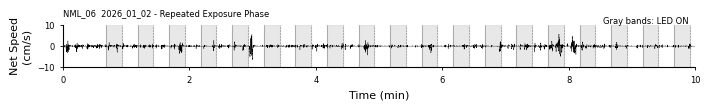

In [262]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# choose a sample session
# --------------------------------------------------
animal = "NML_06"
date = "2026_01_02"   # replace with your representative habituation session

# --------------------------------------------------
# load behavior
# --------------------------------------------------
b = pdio.load_behavior_h5(
    animal,
    date,
    keys=[
        "t",
        "speed_path_cms",
        "speed_net_cms",
        "fs",
        "Air_r",
        "Air_f",
    ]
)

t = np.asarray(b["t"]).reshape(-1).astype(float)
speed_path = np.asarray(b["speed_path_cms"]).reshape(-1).astype(float)
speed_net = np.asarray(b["speed_net_cms"]).reshape(-1).astype(float)

Air_r = np.asarray(b["Air_r"]).reshape(-1).astype(float)
Air_f = np.asarray(b["Air_f"]).reshape(-1).astype(float)

Air_r_idx = Air_r.astype(int)
Air_f_idx = Air_f.astype(int)

n = min(len(t), len(speed_path), len(speed_net))
t = t[:n]
speed_path = speed_path[:n]
speed_net = speed_net[:n]

# start time at zero
t0 = t[0]
t_min = (t - t0) / 60.0

# convert LED onset/offset times to minutes relative to session start
Air_r_min = (t[Air_r_idx] - t0) / 60.0
Air_f_min = (t[Air_f_idx] - t0) / 60.0

# --------------------------------------------------
# figure folder
# --------------------------------------------------
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# plot raw speed trace
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 1))

# speed trace
ax.plot(t_min, speed_net, lw=0.25, color="black", zorder=2)

# LED ON shaded epochs
for on, off in zip(Air_r_min, Air_f_min):
    ax.axvspan(on, off, color="0.85", alpha=0.6, zorder=0)

# optional: vertical lines for ON/OFF
for on in Air_r_min:
    ax.axvline(on, color="0.5", lw=0.4, linestyle="-", zorder=1)

for off in Air_f_min:
    ax.axvline(off, color="0.5", lw=0.4, linestyle="--", zorder=1)

ax.set_xlabel("Time (min)", fontsize=8)
# ax.set_ylabel("Speed\n(cm/s)", fontsize=8)
ax.set_ylabel("Net Speed\n(cm/s)", fontsize=8)
ax.set_title(f"{animal}  {date} - Repeated Exposure Phase", loc="left", fontsize=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ax.set_xlim(0, np.nanmax(t_min))
ax.set_xlim(0, 10)
# ax.set_ylim(np.nanmin(speed_net[speed_net < 0]), np.nanpercentile(speed_net[speed_net > 0], 99.5))
ax.set_ylim(-10, 10)

ax.tick_params(width=0.6, length=2.5, labelsize=6)

# small annotation
ax.text(
    0.99, 1.2,
    "Gray bands: LED ON",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=6
)

fig.tight_layout(pad=0.35)

# --------------------------------------------------
# save
# --------------------------------------------------
fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led_repeated_exposure.pdf")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.svg")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.png", dpi=600)

plt.show()

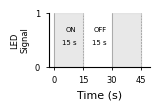

In [259]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# choose a sample session
# --------------------------------------------------
animal = "NML_06"
date = "2026_01_02"   # replace with your representative habituation session

# --------------------------------------------------
# load behavior
# --------------------------------------------------
b = pdio.load_behavior_h5(
    animal,
    date,
    keys=[
        "t",
        "speed_path_cms",
        "speed_net_cms",
        "fs",
        "Air_r",
        "Air_f",
        "air_bin"
    ]
)

t = np.asarray(b["t"]).reshape(-1).astype(float)
speed_path = np.asarray(b["speed_path_cms"]).reshape(-1).astype(float)
speed_net = np.asarray(b["speed_net_cms"]).reshape(-1).astype(float)
air_bin = np.asarray(b["air_bin"]).reshape(-1).astype(float)

Air_r = np.asarray(b["Air_r"]).reshape(-1).astype(float)
Air_f = np.asarray(b["Air_f"]).reshape(-1).astype(float)

Air_r_idx = Air_r.astype(int)
Air_f_idx = Air_f.astype(int)

n = min(len(t), len(speed_path), len(speed_net))
t = t[:n]
speed_path = speed_path[:n]
speed_net = speed_net[:n]
air_bin = air_bin[:n]

# start time at zero
t0 = t[0]+t[Air_r_idx[0]]
t_min = (t - t0) / 60.0
t_sec = t - t0

# convert LED onset/offset times to minutes relative to session start
Air_r_min = (t[Air_r_idx] - t0)# / 60.0
Air_f_min = (t[Air_f_idx] - t0)# / 60.0

# --------------------------------------------------
# figure folder
# --------------------------------------------------
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# plot raw speed trace
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(1.5, 1))

# speed trace
# ax.plot(t_sec, air_bin, lw=0.25, color="black", zorder=2)

# LED ON shaded epochs
for on, off in zip(Air_r_min, Air_f_min):
    ax.axvspan(on, off, color="0.85", alpha=0.6, zorder=0)

# optional: vertical lines for ON/OFF
for on in Air_r_min:
    ax.axvline(on, color="0.5", lw=0.4, linestyle="-", zorder=1)

for off in Air_f_min:
    ax.axvline(off, color="0.5", lw=0.4, linestyle="--", zorder=1)

ax.set_xlabel("Time (s)", fontsize=8)
# ax.set_ylabel("Speed\n(cm/s)", fontsize=8)
ax.set_ylabel("LED\nSignal", fontsize=6)
# ax.set_title(f"{animal}  {date} - Red LED light", loc="left", fontsize=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ax.set_xlim(0, np.nanmax(t_min))
ax.set_xlim(-3, 50)
# ax.set_ylim(np.nanmin(speed_net[speed_net < 0]), np.nanpercentile(speed_net[speed_net > 0], 99.5))
# ax.set_ylim(-10, 10)

ax.set_xticks(np.arange(0, 51, 15))   # 0, 15, 30, 45, 60
ax.set_yticks(np.arange(0, 2, 1))   # 0, 1, 2
ax.tick_params(width=0.6, length=2.5, labelsize=6)

ax.tick_params(width=0.6, length=2.5, labelsize=6)

ax.text(
    0.275, 0.75,
    "ON",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=5
)

ax.text(
    0.275, 0.5,
    "15 s",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=5
)

ax.text(
    0.575, 0.75,
    "OFF",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=5
)

ax.text(
    0.575, 0.5,
    "15 s",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=5
)

fig.tight_layout(pad=0.35)

# --------------------------------------------------
# save
# --------------------------------------------------
fig.savefig(fig_dir / "Figure1B_LED_signal.pdf",dpi=600)
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.svg")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.png", dpi=600)

plt.show()

In [102]:
fig_dir
t_sec

array([ -30.        ,  -29.9998    ,  -29.9996    , ..., 1238.89941406,
       1238.8996582 , 1238.89978027])

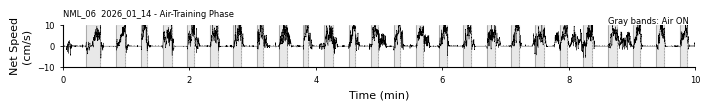

In [265]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# choose a sample session
# --------------------------------------------------
animal = "NML_06"
date = "2026_01_14"   # replace with your representative habituation session

# --------------------------------------------------
# load behavior
# --------------------------------------------------
b = pdio.load_behavior_h5(
    animal,
    date,
    keys=[
        "t",
        "speed_path_cms",
        "speed_net_cms",
        "fs",
        "Air_r",
        "Air_f",
    ]
)

t = np.asarray(b["t"]).reshape(-1).astype(float)
speed_path = np.asarray(b["speed_path_cms"]).reshape(-1).astype(float)
speed_net = np.asarray(b["speed_net_cms"]).reshape(-1).astype(float)

Air_r = np.asarray(b["Air_r"]).reshape(-1).astype(float)
Air_f = np.asarray(b["Air_f"]).reshape(-1).astype(float)

Air_r_idx = Air_r.astype(int)
Air_f_idx = Air_f.astype(int)

n = min(len(t), len(speed_path), len(speed_net))
t = t[:n]
speed_path = speed_path[:n]
speed_net = speed_net[:n]

# start time at zero
t0 = t[0]
t_min = (t - t0) / 60.0

# convert LED onset/offset times to minutes relative to session start
Air_r_min = (t[Air_r_idx] - t0) / 60.0
Air_f_min = (t[Air_f_idx] - t0) / 60.0

# --------------------------------------------------
# figure folder
# --------------------------------------------------
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# plot raw speed trace
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 1))

# speed trace
ax.plot(t_min, speed_net, lw=0.25, color="black", zorder=2)

# LED ON shaded epochs
for on, off in zip(Air_r_min, Air_f_min):
    ax.axvspan(on, off, color="0.85", alpha=0.6, zorder=0)

# optional: vertical lines for ON/OFF
for on in Air_r_min:
    ax.axvline(on, color="0.5", lw=0.4, linestyle="-", zorder=1)

for off in Air_f_min:
    ax.axvline(off, color="0.5", lw=0.4, linestyle="--", zorder=1)

ax.set_xlabel("Time (min)", fontsize=8)
ax.set_ylabel("Net Speed\n(cm/s)", fontsize=8)
ax.set_title(f"{animal}  {date} - Air-Training Phase", loc="left", fontsize=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ax.set_xlim(0, np.nanmax(t_min))
ax.set_xlim(0, 10)
# ax.set_ylim(np.nanmin(speed_net[speed_net < 0]), np.nanpercentile(speed_net[speed_net > 0], 99.5))
ax.set_ylim(-10, 10)

ax.tick_params(width=0.6, length=2.5, labelsize=6)

# small annotation
ax.text(
    0.99, 1.2,
    "Gray bands: Air ON",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=6
)

fig.tight_layout(pad=0.35)

# --------------------------------------------------
# save
# --------------------------------------------------
fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led_air_training.pdf")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.svg")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.png", dpi=600)

plt.show()

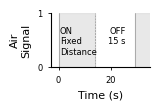

In [260]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# choose a sample session
# --------------------------------------------------
animal = "NML_06"
date = "2026_01_14"   # replace with your representative habituation session

# --------------------------------------------------
# load behavior
# --------------------------------------------------
b = pdio.load_behavior_h5(
    animal,
    date,
    keys=[
        "t",
        "speed_path_cms",
        "speed_net_cms",
        "fs",
        "Air_r",
        "Air_f",
        "air_bin"
    ]
)

t = np.asarray(b["t"]).reshape(-1).astype(float)
speed_path = np.asarray(b["speed_path_cms"]).reshape(-1).astype(float)
speed_net = np.asarray(b["speed_net_cms"]).reshape(-1).astype(float)
air_bin = np.asarray(b["air_bin"]).reshape(-1).astype(float)

Air_r = np.asarray(b["Air_r"]).reshape(-1).astype(float)
Air_f = np.asarray(b["Air_f"]).reshape(-1).astype(float)

Air_r_idx = Air_r.astype(int)
Air_f_idx = Air_f.astype(int)

n = min(len(t), len(speed_path), len(speed_net))
t = t[:n]
speed_path = speed_path[:n]
speed_net = speed_net[:n]
air_bin = air_bin[:n]

# start time at zero
t0 = t[0] + t[Air_r_idx[0]]  # add 1 sec to align with Air ON
t_min = (t - t0)# / 60.0

# convert LED onset/offset times to minutes relative to session start
Air_r_min = (t[Air_r_idx] - t0)# / 60.0
Air_f_min = (t[Air_f_idx] - t0)# / 60.0

# --------------------------------------------------
# figure folder
# --------------------------------------------------
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# plot raw speed trace
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(1.5, 1))

# speed trace
# ax.plot(t_min, speed_net, lw=0.25, color="black", zorder=2)

# LED ON shaded epochs
for on, off in zip(Air_r_min, Air_f_min):
    ax.axvspan(on, off, color="0.85", alpha=0.6, zorder=0)

# optional: vertical lines for ON/OFF
for on in Air_r_min:
    ax.axvline(on, color="0.5", lw=0.4, linestyle="-", zorder=1)

for off in Air_f_min:
    ax.axvline(off, color="0.5", lw=0.4, linestyle="--", zorder=1)

ax.set_xlabel("Time (s)", fontsize=8)
ax.set_ylabel("Air\nSignal", fontsize=8)
# ax.set_title(f"{animal}  {date} - Air-Training Phase", loc="left", fontsize=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ax.set_xlim(0, np.nanmax(t_min))
ax.set_xlim(-3, 35)
# ax.set_ylim(np.nanmin(speed_net[speed_net < 0]), np.nanpercentile(speed_net[speed_net > 0], 99.5))
# ax.set_ylim(-10, 10)
ax.set_yticks(np.arange(0, 2, 1))   # 0, 1, 2

ax.tick_params(width=0.6, length=2.5, labelsize=6)

# small annotation
ax.text(
    0.09, 0.75,
    "ON\nFixed\nDistance",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=6
)
ax.text(
    0.75, 0.75,
    "OFF\n15 s",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=6
)
fig.tight_layout(pad=0.35)
# --------------------------------------------------
# save
# --------------------------------------------------
fig.savefig(fig_dir / "Figure1B_Air_signal.pdf")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.svg")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.png", dpi=600)

plt.show()

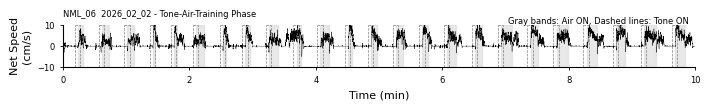

In [269]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# choose a sample session
# --------------------------------------------------
animal = "NML_06"
date = "2026_02_02"  # replace with your representative habituation session

# --------------------------------------------------
# load behavior
# --------------------------------------------------
b = pdio.load_behavior_h5(
    animal,
    date,
    keys=[
        "t",
        "speed_path_cms",
        "speed_net_cms",
        "fs",
        "Air_r",
        "Air_f",
    ]
)

t = np.asarray(b["t"]).reshape(-1).astype(float)
speed_path = np.asarray(b["speed_path_cms"]).reshape(-1).astype(float)
speed_net = np.asarray(b["speed_net_cms"]).reshape(-1).astype(float)

Air_r = np.asarray(b["Air_r"]).reshape(-1).astype(float)
Air_f = np.asarray(b["Air_f"]).reshape(-1).astype(float)

Air_r_idx = Air_r.astype(int)
Air_f_idx = Air_f.astype(int)

n = min(len(t), len(speed_path), len(speed_net))
t = t[:n]
speed_path = speed_path[:n]
speed_net = speed_net[:n]

# start time at zero
t0 = t[0]
t_min = (t - t0) / 60.0

# convert LED onset/offset times to minutes relative to session start
Air_r_min = (t[Air_r_idx] - t0) / 60.0
Air_f_min = (t[Air_f_idx] - t0) / 60.0

# --------------------------------------------------
# figure folder
# --------------------------------------------------
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# plot raw speed trace
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 1))

# speed trace
ax.plot(t_min, speed_net, lw=0.25, color="black", zorder=2)

# LED ON shaded epochs
for on, off in zip(Air_r_min, Air_f_min):
    ax.axvspan(on, off, color="0.85", alpha=0.6, zorder=0)
    # ax.axvspan(on-(3/60), on+(2/60), color="0.5", alpha=0.2, zorder=0)

# optional: vertical lines for ON/OFF
for on in Air_r_min:
    ax.axvline(on-(3/60), color="0.5", lw=0.5, linestyle="--", zorder=1)
    ax.axvline(on+(2/60), color="0.5", lw=0.5, linestyle="--", zorder=1)
    ax.hlines(y=10,xmin = on-(3/60), xmax=on+(2/60), color="0.5", lw=0.5, linestyle="--", zorder=1)
    # ax.axvline(on, color="0.5", lw=0.4, linestyle="-", zorder=1)

# for off in Air_f_min:
#     ax.axvline(off, color="0.5", lw=0.4, linestyle="--", zorder=1)

ax.set_xlabel("Time (min)", fontsize=8)
ax.set_ylabel("Net Speed\n(cm/s)", fontsize=8)
ax.set_title(f"{animal}  {date} - Tone-Air-Training Phase", loc="left", fontsize=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ax.set_xlim(0, np.nanmax(t_min))
ax.set_xlim(0, 10)
# ax.set_ylim(np.nanmin(speed_net[speed_net < 0]), np.nanpercentile(speed_net[speed_net > 0], 99.5))
ax.set_ylim(-10, 10)

ax.tick_params(width=0.6, length=2.5, labelsize=6)

# small annotation
ax.text(
    0.99, 1.2,
    "Gray bands: Air ON, Dashed lines: Tone ON",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=6
)

fig.tight_layout(pad=0.35)

# --------------------------------------------------
# save
# --------------------------------------------------
fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led_tone_air_training.pdf")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.svg")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.png", dpi=600)

plt.show()

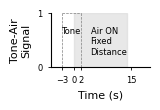

In [261]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# choose a sample session
# --------------------------------------------------
animal = "NML_06"
date = "2026_01_14"   # replace with your representative habituation session

# --------------------------------------------------
# load behavior
# --------------------------------------------------
b = pdio.load_behavior_h5(
    animal,
    date,
    keys=[
        "t",
        "speed_path_cms",
        "speed_net_cms",
        "fs",
        "Air_r",
        "Air_f",
        "air_bin"
    ]
)

t = np.asarray(b["t"]).reshape(-1).astype(float)
speed_path = np.asarray(b["speed_path_cms"]).reshape(-1).astype(float)
speed_net = np.asarray(b["speed_net_cms"]).reshape(-1).astype(float)
air_bin = np.asarray(b["air_bin"]).reshape(-1).astype(float)

Air_r = np.asarray(b["Air_r"]).reshape(-1).astype(float)
Air_f = np.asarray(b["Air_f"]).reshape(-1).astype(float)

Air_r_idx = Air_r.astype(int)
Air_f_idx = Air_f.astype(int)

n = min(len(t), len(speed_path), len(speed_net))
t = t[:n]
speed_path = speed_path[:n]
speed_net = speed_net[:n]
air_bin = air_bin[:n]

# start time at zero
t0 = t[0] + t[Air_r_idx[0]]  # add 1 sec to align with Air ON
t_min = (t - t0)# / 60.0

# convert LED onset/offset times to minutes relative to session start
Air_r_min = (t[Air_r_idx] - t0)# / 60.0
Air_f_min = (t[Air_f_idx] - t0)# / 60.0

# --------------------------------------------------
# figure folder
# --------------------------------------------------
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# plot raw speed trace
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(1.5, 1))

# speed trace
# ax.plot(t_min, speed_net, lw=0.25, color="black", zorder=2)

# LED ON shaded epochs
for on, off in zip(Air_r_min, Air_f_min):
    ax.axvspan(on, off, color="0.85", alpha=0.6, zorder=0)

# # optional: vertical lines for ON/OFF
# for on in Air_r_min:
#     ax.axvline(on, color="0.5", lw=0.4, linestyle="-", zorder=1)

# for off in Air_f_min:
#     ax.axvline(off, color="0.5", lw=0.4, linestyle="--", zorder=1)

ax.set_xlabel("Time (s)", fontsize=8)
ax.set_ylabel("Tone-Air\nSignal", fontsize=8)
# ax.set_title(f"{animal}  {date} - Air-Training Phase", loc="left", fontsize=6)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ax.set_xlim(0, np.nanmax(t_min))
ax.set_xlim(-6,20)
# ax.set_ylim(np.nanmin(speed_net[speed_net < 0]), np.nanpercentile(speed_net[speed_net > 0], 99.5))

ax.set_yticks(np.arange(0, 2, 1))   # 0, 1, 2
ax.set_xticks([-3,0,2,15])   # 0, 1, 2

ax.tick_params(width=0.6, length=2.5, labelsize=6)
ax.axvline(-3, color="0.5", lw=0.5, linestyle="--", zorder=1)
ax.axvline(2, color="0.5", lw=0.5, linestyle="--", zorder=1)
ax.hlines(y=1,xmin = -3, xmax=2, color="0.5", lw=0.5, linestyle="--", zorder=1)
ax.set_ylim(0, 1)
# small annotation
ax.text(
    0.4, 0.75,
    "Air ON\nFixed\nDistance",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=6
)
ax.text(
    0.102, 0.75,
    "Tone",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=6
)

fig.tight_layout(pad=0.35)
# --------------------------------------------------
# save
# --------------------------------------------------
fig.savefig(fig_dir / "Figure1B_Tone_Air_signal.pdf")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.svg")
# fig.savefig(fig_dir / "Figure1B_raw_speed_trace_led.png", dpi=600)

plt.show()

In [48]:
%connect_info

{"key":"989945ba-17d0-4625-9e60-6ee570ef0593","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9031,"control_port":9032,"shell_port":9033,"stdin_port":9034,"iopub_port":9035,"kernel_name":"python3820jvsc74a57bd07f6243129cfff82ede3c5c59589229000c07b9cd1160ea9b86b0dd361ed08050"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing /run/user/1000/jupyter/runtime/kernel-v3961c19f4bd1a1f1c720cc9fe6fec305419623d17.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


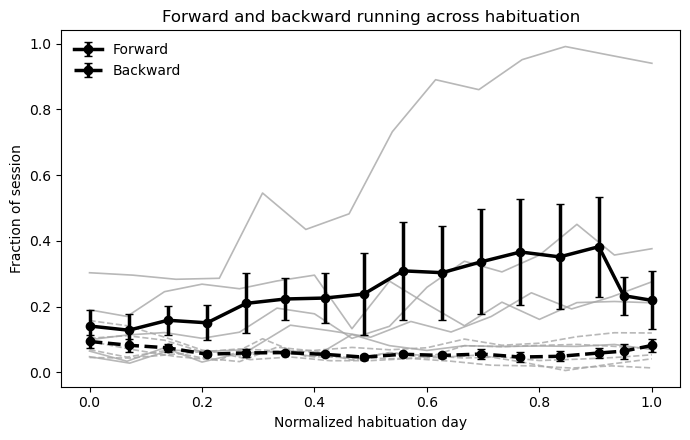

In [3]:
from src.vis.plots import plot_habituation_forward_backward

fig, ax, hab_fb_summary = plot_habituation_forward_backward(hab_session_df)

In [99]:
def make_habituation_direction_daybin_df(hab_session_df):
    """
    Make animal × day-bin × direction table for RM-ANOVA.
    """

    daybin_df = (
        hab_session_df
        .groupby(["animal", "phase_day_bin"], dropna=False)
        .agg(
            frac_forward=("frac_forward", "mean"),
            frac_backward=("frac_backward", "mean"),
            frac_stationary=("frac_stationary", "mean"),
            mean_speed_path_cms=("mean_speed_path_cms", "mean"),
            n_sessions=("date", "nunique"),
        )
        .reset_index()
    )

    long_df = daybin_df.melt(
        id_vars=["animal", "phase_day_bin", "n_sessions"],
        value_vars=["frac_forward", "frac_backward"],
        var_name="direction",
        value_name="frac_locomotor_state"
    )

    long_df["direction"] = long_df["direction"].replace({
        "frac_forward": "forward",
        "frac_backward": "backward",
    })

    long_df["phase_day_bin"] = pd.Categorical(
        long_df["phase_day_bin"],
        categories=["early", "middle", "late"],
        ordered=True
    )

    long_df["direction"] = pd.Categorical(
        long_df["direction"],
        categories=["backward", "forward"],
        ordered=True
    )

    return long_df

In [100]:
hab_direction_rm_df = make_habituation_direction_daybin_df(hab_session_df)

hab_direction_rm_df.groupby("animal").size().reset_index(name="n_cells")

KeyError: 'phase_day_bin'

In [6]:
from statsmodels.stats.anova import AnovaRM

aov_hab_direction = AnovaRM(
    data=hab_direction_rm_df,
    depvar="frac_locomotor_state",
    subject="animal",
    within=["phase_day_bin", "direction"]
).fit()

print(aov_hab_direction)

                       Anova
                        F Value Num DF Den DF Pr > F
----------------------------------------------------
phase_day_bin            3.1368 2.0000 8.0000 0.0987
direction                3.6664 1.0000 4.0000 0.1280
phase_day_bin:direction  3.0838 2.0000 8.0000 0.1017



In [3]:
df0 = encoder_epoch_df.copy()

In [4]:
# --------------------------------------------------
# Create habituation epoch dataframe from encoder_epoch_df
# --------------------------------------------------

df0 = encoder_epoch_df.copy()

print("Available phases:")
print(df0["phase"].value_counts())

# Detect habituation phase name
hab_phase_candidates = [
    p for p in df0["phase"].dropna().astype(str).unique()
    if ("hab" in p.lower()) or ("exposure" in p.lower())
]

print("Habituation phase candidates:", hab_phase_candidates)

hab_phase = hab_phase_candidates[0]
print("Using habituation phase:", hab_phase)

hab_epoch_df = df0[df0["phase"].astype(str) == hab_phase].copy()

# Keep valid windows if available
if "valid_window" in hab_epoch_df.columns:
    hab_epoch_df = hab_epoch_df[hab_epoch_df["valid_window"] == True].copy()

if "good_session_basic" in hab_epoch_df.columns:
    hab_epoch_df = hab_epoch_df[hab_epoch_df["good_session_basic"] == True].copy()

print("hab_epoch_df:", hab_epoch_df.shape)

Available phases:
phase
air_training         42362
habituation          38237
tone_air_training    21262
Name: count, dtype: int64
Habituation phase candidates: ['habituation']
Using habituation phase: habituation
hab_epoch_df: (38237, 59)


In [5]:
# --------------------------------------------------
# Add animal-day/session ID
# --------------------------------------------------

hab_epoch_df["animal_day"] = (
    hab_epoch_df["animal"].astype(str) + ":" +
    hab_epoch_df["date"].astype(str)
)

# --------------------------------------------------
# Exposure session number
# --------------------------------------------------

if "exposure_session" not in hab_epoch_df.columns:
    if "phase_session_number" in hab_epoch_df.columns:
        hab_epoch_df["exposure_session"] = hab_epoch_df["phase_session_number"]
    elif "phase_day_number_good" in hab_epoch_df.columns:
        hab_epoch_df["exposure_session"] = hab_epoch_df["phase_day_number_good"]
    elif "phase_day" in hab_epoch_df.columns:
        hab_epoch_df["exposure_session"] = hab_epoch_df["phase_day"]
    else:
        raise ValueError("Could not find exposure/session/day column.")

hab_epoch_df["exposure_session"] = hab_epoch_df["exposure_session"].astype(float)

hab_epoch_df["exposure_session_c"] = (
    hab_epoch_df["exposure_session"] -
    hab_epoch_df["exposure_session"].mean()
)

# --------------------------------------------------
# Session time in minutes
# --------------------------------------------------

if "session_time_min" not in hab_epoch_df.columns:
    if "anchor_session_time_min" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["anchor_session_time_min"]
    elif "window_center_time_s" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["window_center_time_s"] / 60.0
    elif "anchor_time_s" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["anchor_time_s"] / 60.0
    elif "session_time_s" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["session_time_s"] / 60.0
    else:
        raise ValueError("Could not find session-time column.")

hab_epoch_df["session_time_10m_c"] = (
    hab_epoch_df["session_time_min"] -
    hab_epoch_df["session_time_min"].mean()
) / 10.0

print("Mean session time subtracted:", hab_epoch_df["session_time_min"].mean())

print("\nSession time summary:")
display(hab_epoch_df["session_time_min"].describe())

print("\nExposure session summary:")
display(hab_epoch_df["exposure_session"].describe())

print("\nFinal hab_epoch_df:", hab_epoch_df.shape)
display(hab_epoch_df.head())


Mean session time subtracted: 11.397382056126363

Session time summary:


count    38237.000000
mean        11.397382
std          6.702021
min          0.035327
25%          5.813273
50%         11.197920
75%         16.561718
max         42.373018
Name: session_time_min, dtype: float64


Exposure session summary:


count    38237.000000
mean         9.539765
std          4.973974
min          1.000000
25%          5.000000
50%         10.000000
75%         14.000000
max         19.000000
Name: exposure_session, dtype: float64


Final hab_epoch_df: (38237, 64)


,animal,date,phase,event_number,anchor_name,anchor_type,anchor_time_s,window_position,window_s,epoch_name,...,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,animal_day,exposure_session,exposure_session_c,session_time_min,session_time_10m_c
42362,NML_04,2025_12_27,habituation,0,LED_off_mid,middle,94.519501,post,1.0,LED_off_mid_post_1s,...,0.7754,0.4378,0.3376,0.0,forward,NML_04:2025_12_27,1.0,-8.539765,1.575325,-0.982206
42363,NML_04,2025_12_27,habituation,0,LED_off_mid,middle,94.519501,pre,1.0,LED_off_mid_pre_1s,...,0.8246,0.4530,0.3716,0.0,forward,NML_04:2025_12_27,1.0,-8.539765,1.575325,-0.982206
42364,NML_04,2025_12_27,habituation,0,LED_off,main,87.027199,post,1.0,LED_off_post_1s,...,0.0000,0.0000,0.0000,0.0,stationary,NML_04:2025_12_27,1.0,-8.539765,1.450453,-0.994693
42365,NML_04,2025_12_27,habituation,0,LED_off,main,87.027199,pre,1.0,LED_off_pre_1s,...,0.3184,0.2738,0.0446,0.0,stationary,NML_04:2025_12_27,1.0,-8.539765,1.450453,-0.994693
42366,NML_04,2025_12_27,habituation,0,LED_on_mid,middle,79.535099,post,1.0,LED_on_mid_post_1s,...,0.0000,0.0000,0.0000,0.0,stationary,NML_04:2025_12_27,1.0,-8.539765,1.325585,-1.007180


In [6]:
# --------------------------------------------------
# Create a session-level dataframe if needed
# One row per animal-day/session
# --------------------------------------------------

primary_outcomes = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

primary_outcomes = [x for x in primary_outcomes if x in hab_epoch_df.columns]

group_cols = [
    "animal",
    "date",
    "animal_day",
    "exposure_session",
]

hab_session_df = (
    hab_epoch_df
    .groupby(group_cols, observed=True)[primary_outcomes]
    .mean()
    .reset_index()
)

hab_session_df["exposure_session_c"] = (
    hab_session_df["exposure_session"] -
    hab_session_df["exposure_session"].mean()
)

print("hab_session_df:", hab_session_df.shape)
display(hab_session_df.head())

hab_session_df: (85, 8)


,animal,date,animal_day,exposure_session,frac_moving,frac_forward,mean_speed_path_cms,exposure_session_c
0,NML_04,2025_12_27,NML_04:2025_12_27,1.0,0.357151,0.193729,0.798838,-8.211765
1,NML_04,2025_12_28,NML_04:2025_12_28,2.0,0.295409,0.162599,0.540097,-7.211765
2,NML_04,2025_12_29,NML_04:2025_12_29,3.0,0.338581,0.230797,0.688970,-6.211765
3,NML_04,2025_12_30,NML_04:2025_12_30,4.0,0.332259,0.264549,0.912839,-5.211765
4,NML_04,2025_12_31,NML_04:2025_12_31,5.0,0.322373,0.277843,0.927110,-4.211765


In [8]:
%load_ext rpy2.ipython

In [10]:
%%R -i hab_session_df -i hab_epoch_df -o hab_session_results_R -o hab_epoch_results_R

library(lme4)
library(lmerTest)
library(broom.mixed)
library(dplyr)
# library(ggeffects)
# library(ggplot2)

# --------------------------------------------------
# Prepare factors
# --------------------------------------------------

hab_session_df$animal <- factor(hab_session_df$animal)
hab_epoch_df$animal <- factor(hab_epoch_df$animal)
hab_epoch_df$animal_day <- factor(hab_epoch_df$animal_day)

# --------------------------------------------------
# Outcomes to run
# Use only primary outcomes
# --------------------------------------------------

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

print(primary_outcomes)

# --------------------------------------------------
# Whole-session models
# --------------------------------------------------

session_results <- list()
session_models <- list()

for (outcome in primary_outcomes) {

  formula_text <- paste0(
    outcome,
    " ~ exposure_session_c + (1 | animal)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = hab_session_df,
    REML = FALSE
  )

  session_models[[outcome]] <- m

  tmp <- broom.mixed::tidy(
    m,
    effects = "fixed",
    conf.int = TRUE
  )

  tmp$outcome <- outcome
  session_results[[outcome]] <- tmp
}

hab_session_results_R <- bind_rows(session_results) %>%
  relocate(outcome)

print(hab_session_results_R)

# --------------------------------------------------
# Epoch/session-time models
# --------------------------------------------------

epoch_results <- list()
epoch_models <- list()

primary_epoch_outcomes <- primary_outcomes[
  primary_outcomes %in% names(hab_epoch_df)
]

for (outcome in primary_epoch_outcomes) {

  formula_text <- paste0(
    outcome,
    " ~ exposure_session_c * session_time_10m_c + ",
    "(1 | animal) + (1 | animal_day)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = hab_epoch_df,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  epoch_models[[outcome]] <- m

  tmp <- broom.mixed::tidy(
    m,
    effects = "fixed",
    conf.int = TRUE
  )

  tmp$outcome <- outcome
  epoch_results[[outcome]] <- tmp
}

hab_epoch_results_R <- bind_rows(epoch_results) %>%
  relocate(outcome)

print(hab_epoch_results_R)

[1] "frac_moving"         "frac_forward"        "mean_speed_path_cms"
# A tibble: 6 × 10
  outcome       effect term  estimate std.error statistic    df p.value conf.low
  <chr>         <chr>  <chr>    <dbl>     <dbl>     <dbl> <dbl>   <dbl>    <dbl>
1 frac_moving   fixed  (Int…   0.326    0.0783       4.16  5.03 8.73e-3   0.125 
2 frac_moving   fixed  expo…   0.0175   0.00312      5.61 80.2  2.74e-7   0.0113
3 frac_forward  fixed  (Int…   0.258    0.0773       3.34  5.03 2.04e-2   0.0596
4 frac_forward  fixed  expo…   0.0209   0.00302      6.91 80.2  1.05e-9   0.0149
5 mean_speed_p… fixed  (Int…   1.74     0.865        2.01  5.04 1.00e-1  -0.481 
6 mean_speed_p… fixed  expo…   0.247    0.0400       6.19 80.3  2.39e-8   0.168 
# ℹ 1 more variable: conf.high <dbl>
# A tibble: 12 × 10
   outcome    effect term  estimate std.error statistic     df  p.value conf.low
   <chr>      <chr>  <chr>    <dbl>     <dbl>     <dbl>  <dbl>    <dbl>    <dbl>
 1 frac_movi… fixed  (Int…  3.32e-1  0.0809 

In [12]:
import pandas as pd
import numpy as np

def format_p(p):
    if pd.isna(p):
        return "p = NA"
    elif p < 0.001:
        return "p < 0.001"
    else:
        return f"p = {p:.3f}"

def make_lme_report_table(df):
    report_df = df.copy()

    report_df["report_text"] = report_df.apply(
        lambda r: (
            f"β = {r['estimate']:.4f}, "
            f"SE = {r['std.error']:.4f}, "
            f"t({r['df']:.1f}) = {r['statistic']:.2f}, "
            f"{format_p(r['p.value'])}"
        ),
        axis=1
    )

    return report_df[
        ["outcome", "term", "estimate", "std.error", "statistic", "df", "p.value", "report_text"]
    ]

hab_session_report = make_lme_report_table(hab_session_results_R)
hab_epoch_report = make_lme_report_table(hab_epoch_results_R)

print("Whole-session LME report:")
display(hab_session_report)

print("Epoch/session-time LME report:")
display(hab_epoch_report)

Whole-session LME report:


,outcome,term,estimate,std.error,statistic,df,p.value,report_text
1,frac_moving,(Intercept),0.325654,0.078295,4.159340,5.026274,8.730899e-03,"β = 0.3257, SE = 0.0783, t(5.0) = 4.16, p = 0.009"
2,frac_moving,exposure_session_c,0.017524,0.003121,5.614723,80.190442,2.737459e-07,"β = 0.0175, SE = 0.0031, t(80.2) = 5.61, p < 0..."
3,frac_forward,(Intercept),0.257964,0.077274,3.338311,5.025804,2.043067e-02,"β = 0.2580, SE = 0.0773, t(5.0) = 3.34, p = 0.020"
4,frac_forward,exposure_session_c,0.020881,0.003022,6.909912,80.183831,1.046930e-09,"β = 0.0209, SE = 0.0030, t(80.2) = 6.91, p < 0..."
5,mean_speed_path_cms,(Intercept),1.738609,0.865446,2.008918,5.042073,1.003109e-01,"β = 1.7386, SE = 0.8654, t(5.0) = 2.01, p = 0.100"
6,mean_speed_path_cms,exposure_session_c,0.247419,0.039963,6.191164,80.261212,2.393628e-08,"β = 0.2474, SE = 0.0400, t(80.3) = 6.19, p < 0..."


Epoch/session-time LME report:


,outcome,term,estimate,std.error,statistic,df,p.value,report_text
1,frac_moving,(Intercept),0.332263,0.080894,4.107381,5.013309,9.235695e-03,"β = 0.3323, SE = 0.0809, t(5.0) = 4.11, p = 0.009"
2,frac_moving,exposure_session_c,0.016999,0.002905,5.852234,74.171723,1.229021e-07,"β = 0.0170, SE = 0.0029, t(74.2) = 5.85, p < 0..."
3,frac_moving,session_time_10m_c,-0.031707,0.002677,-11.842426,38231.184582,2.682720e-32,"β = -0.0317, SE = 0.0027, t(38231.2) = -11.84,..."
4,frac_moving,exposure_session_c:session_time_10m_c,0.000439,0.000526,0.834789,38232.026198,4.038420e-01,"β = 0.0004, SE = 0.0005, t(38232.0) = 0.83, p ..."
5,frac_forward,(Intercept),0.266368,0.079740,3.340440,5.015115,2.044880e-02,"β = 0.2664, SE = 0.0797, t(5.0) = 3.34, p = 0.020"
6,frac_forward,exposure_session_c,0.020166,0.002883,6.995869,76.201404,8.841029e-10,"β = 0.0202, SE = 0.0029, t(76.2) = 7.00, p < 0..."
7,frac_forward,session_time_10m_c,-0.016264,0.002303,-7.062499,38229.814204,1.663219e-12,"β = -0.0163, SE = 0.0023, t(38229.8) = -7.06, ..."
8,frac_forward,exposure_session_c:session_time_10m_c,-0.000239,0.000453,-0.529180,38228.464157,5.966836e-01,"β = -0.0002, SE = 0.0005, t(38228.5) = -0.53, ..."
9,mean_speed_path_cms,(Intercept),1.824483,0.873400,2.088944,5.041239,9.056502e-02,"β = 1.8245, SE = 0.8734, t(5.0) = 2.09, p = 0.091"
10,mean_speed_path_cms,exposure_session_c,0.245672,0.039875,6.161047,79.812871,2.767005e-08,"β = 0.2457, SE = 0.0399, t(79.8) = 6.16, p < 0..."
